# Binary Detection of AI-Generated Art

A reproducible PyTorch workflow inspired by **ArtBrain / AI-ArtBench** (Silva et al., 2024). The target is binary: `0 = Human/Real`, `1 = AI/Fake`.

Scientific safeguards in this notebook:

- the published test partition remains held out;
- model selection by validation F1, never test F1;
- exact real/fake, generator, and style quotas in every split;
- E4 is called a simplified SE ablation, not a reproduction of AttentionConvNeXt;
- no results are claimed until the cells have run on the actual dataset.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from IPython.display import display
from torch import nn

from ai_art_detection.config import ProjectConfig
from ai_art_detection.data import (
    coursework_split, scan_dataset, seed_everything, validate_dataset_inventory,
)
from ai_art_detection.evaluation import (
    evaluate_robustness, plot_confusion, plot_roc,
    source_error_summary, style_metrics,
)
from ai_art_detection.experiments import (
    DEFAULT_EXPERIMENTS, load_experiment_checkpoint, run_experiment,
)
from ai_art_detection.gradcam import save_gradcam_panels

CONFIG = ProjectConfig(
    data_root=ROOT / "data/raw/real-ai-art",
    output_dir=ROOT / "outputs",
    epochs=8,
)
CONFIG.make_output_dirs()
seed_everything(CONFIG.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Dataset:", CONFIG.data_root)

/home/utente/miniconda3/lib/python3.12/site-packages/torch/cuda/__init__.py:56: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Device: cuda
Dataset: /home/utente/giuseppe/intro_ml_2/data/raw/real-ai-art


## 1. Scan and audit labels

Inspect these tables before continuing. Unknown labels usually mean the downloaded folder names need a new alias in `data.py`.

In [2]:
df_all = scan_dataset(CONFIG.data_root)
validate_dataset_inventory(df_all)
print("Images:", len(df_all))
display(df_all.head())
display(df_all["binary_name"].value_counts(dropna=False).rename("count"))
display(df_all["source_label"].value_counts(dropna=False).rename("count"))
display(df_all["style_label"].value_counts(dropna=False).rename("count"))
display(pd.crosstab(df_all.official_split, df_all.source_label))

Images: 185015


,image_path,source_label,binary_label,binary_name,style_label,official_split,extension
0,/home/utente/giuseppe/intro_ml_2/data/raw/real...,Latent_Diffusion,1,Fake/AI,Art_Nouveau,test,.jpg
1,/home/utente/giuseppe/intro_ml_2/data/raw/real...,Latent_Diffusion,1,Fake/AI,Art_Nouveau,test,.jpg
2,/home/utente/giuseppe/intro_ml_2/data/raw/real...,Latent_Diffusion,1,Fake/AI,Art_Nouveau,test,.jpg
3,/home/utente/giuseppe/intro_ml_2/data/raw/real...,Latent_Diffusion,1,Fake/AI,Art_Nouveau,test,.jpg
4,/home/utente/giuseppe/intro_ml_2/data/raw/real...,Latent_Diffusion,1,Fake/AI,Art_Nouveau,test,.jpg


binary_name
Fake/AI       125015
Real/Human     60000
Name: count, dtype: int64

source_label
Stable_Diffusion    62923
Latent_Diffusion    62092
Human               60000
Name: count, dtype: int64

style_label
Romanticism           18891
Ukiyo_e               18812
Surrealism            18748
Impressionism         18596
Realism               18480
Renaissance           18476
Expressionism         18420
Art_Nouveau           18376
Post_Impressionism    18204
Baroque               18012
Name: count, dtype: int64

source_label,Human,Latent_Diffusion,Stable_Diffusion
official_split,,,
test,10000,10000,10000
train,50000,52092,52923


,width,height,count
0,256,256,675
1,768,768,325


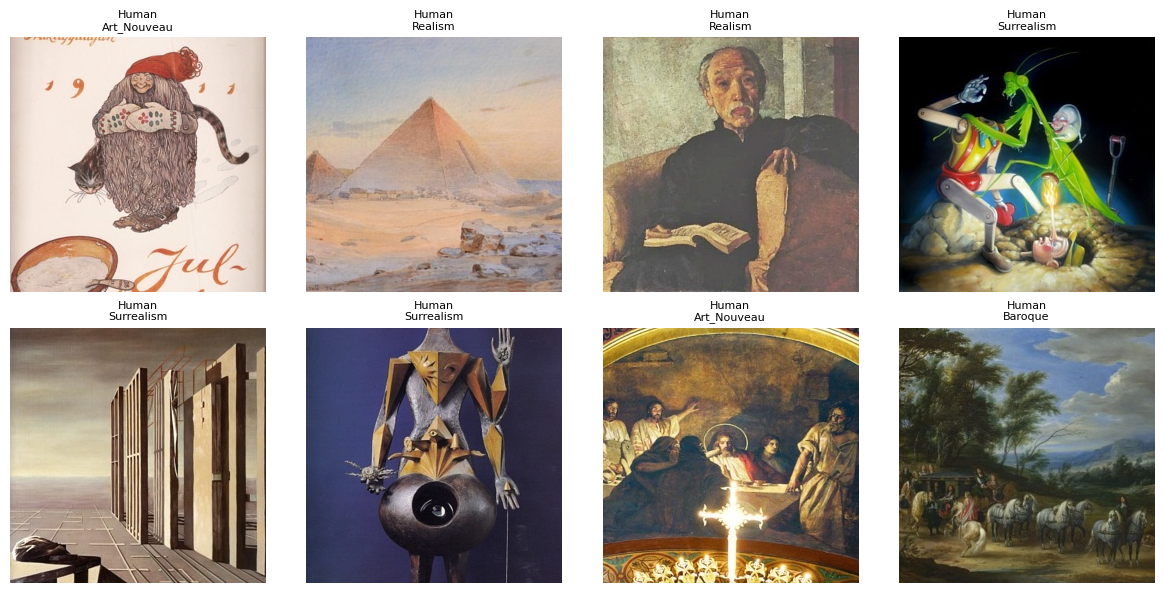

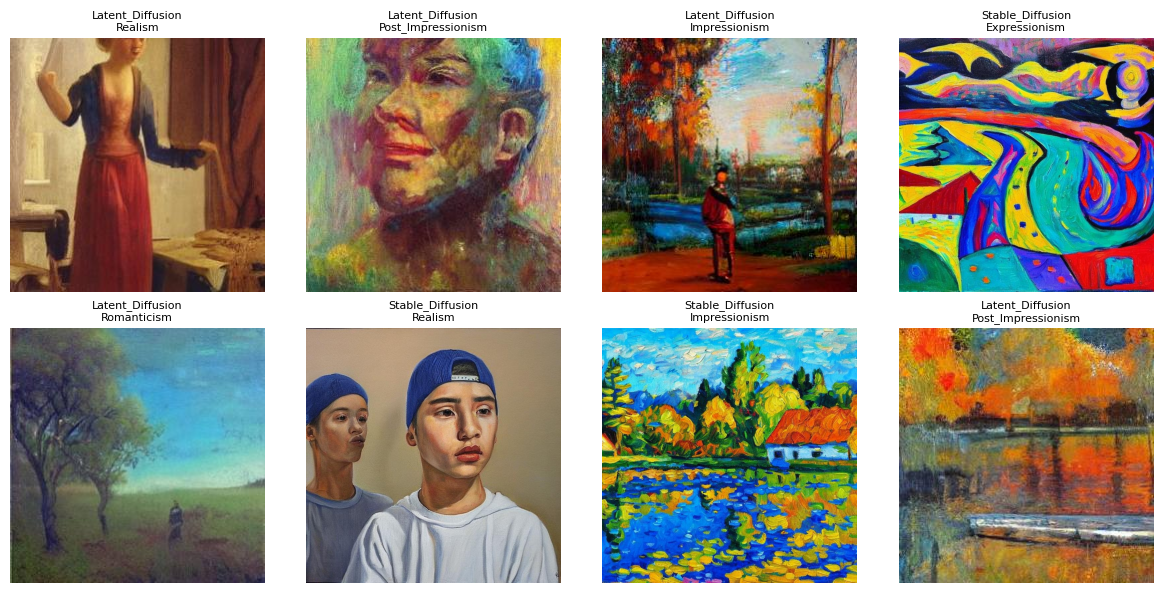

In [3]:
def inspect_sizes(frame, n=1_000):
    rows = []
    for path in frame.sample(min(n, len(frame)), random_state=CONFIG.seed)["image_path"]:
        try:
            with Image.open(path) as image:
                rows.append((image.width, image.height))
        except OSError:
            rows.append((None, None))
    return (pd.DataFrame(rows, columns=["width", "height"])
            .value_counts().rename("count").reset_index())

size_counts = inspect_sizes(df_all)
display(size_counts.head(20))
size_counts.to_csv(CONFIG.output_dir / "tables/image_size_counts_sample.csv", index=False)

def show_grid(frame, label, n=8):
    candidates = frame[frame.binary_label == label]
    sample = candidates.sample(min(n, len(candidates)), random_state=CONFIG.seed)
    figure, axes = plt.subplots(2, 4, figsize=(12, 6))
    for axis, (_, row) in zip(axes.flat, sample.iterrows()):
        with Image.open(row.image_path) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(f"{row.source_label}\n{row.style_label}", fontsize=8)
        axis.axis("off")
    figure.tight_layout()
    name = "real" if label == 0 else "fake"
    figure.savefig(CONFIG.output_dir / f"figures/random_grid_{name}.png", dpi=200)
    plt.show()

show_grid(df_all, 0)
show_grid(df_all, 1)

## 2. Official, balanced coursework splits

Training and validation are sampled only from the official training pool; test images come only from the published test pool. Every source/style cell has an exact quota.

In [4]:
train_df, val_df, test_df = coursework_split(df_all, seed=CONFIG.seed)
for name, frame in (("train", train_df), ("val", val_df), ("test", test_df)):
    print(f"\n{name}: {len(frame)}")
    display(pd.crosstab(frame.binary_name, frame.source_label))
    frame.to_csv(CONFIG.output_dir / f"tables/{name}_split.csv", index=False)


train: 6400


source_label,Human,Latent_Diffusion,Stable_Diffusion
binary_name,,,
Fake/AI,0,1600,1600
Real/Human,3200,0,0



val: 1600


source_label,Human,Latent_Diffusion,Stable_Diffusion
binary_name,,,
Fake/AI,0,400,400
Real/Human,800,0,0



test: 2000


source_label,Human,Latent_Diffusion,Stable_Diffusion
binary_name,,,
Fake/AI,0,500,500
Real/Human,1000,0,0


## 3. Train experiments

The final notebook runs E0--E4. For a quick pipeline check, temporarily slice this tuple to `DEFAULT_EXPERIMENTS[:1]`. ImageNet weights download on first use.

In [5]:
for experiment in DEFAULT_EXPERIMENTS:
    print(experiment)

EXPERIMENTS_TO_RUN = DEFAULT_EXPERIMENTS
results_path = CONFIG.output_dir / "tables/experiment_results.csv"
trained_models = {}
expected_names = {experiment.name for experiment in EXPERIMENTS_TO_RUN}
reuse_results = False
if results_path.exists():
    existing_results = pd.read_csv(results_path)
    reuse_results = set(existing_results.exp_name) == expected_names

if reuse_results:
    print("Reusing the complete measured E0--E4 result set.")
    results_df = existing_results.sort_values("val_f1", ascending=False)
else:
    results = []
    for experiment in EXPERIMENTS_TO_RUN:
        print(f"\nRunning {experiment.name}")
        model, result = run_experiment(
            experiment, train_df, val_df, test_df, CONFIG, device,
        )
        trained_models[experiment.name] = model
        results.append(result)
        display(pd.Series(result))
    results_df = pd.DataFrame(results).sort_values("val_f1", ascending=False)
    results_df.to_csv(results_path, index=False)
display(results_df)

Experiment(name='E0_mobilenetv2_noaug_frozen', model_name='mobilenet_v2', mode='frozen', augment=False)
Experiment(name='E1_mobilenetv2_aug_frozen', model_name='mobilenet_v2', mode='frozen', augment=True)
Experiment(name='E2_convnext_tiny_aug_frozen', model_name='convnext_tiny', mode='frozen', augment=True)
Experiment(name='E3_convnext_tiny_aug_laststage', model_name='convnext_tiny', mode='last_stage', augment=True)
Experiment(name='E4_convnext_tiny_se_aug_laststage', model_name='convnext_tiny_se', mode='last_stage', augment=True)
Reusing the complete measured E0--E4 result set.


,exp_name,model_name,mode,augment,best_epoch,best_val_f1,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,val_loss,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_loss,trainable_params,time_min
0,E3_convnext_tiny_aug_laststage,convnext_tiny,last_stage,True,8,0.991870,0.991875,0.992491,0.99125,0.991870,0.999267,0.033917,0.9915,0.988083,0.995,0.991530,0.999431,0.032047,14291713,0.842619
1,E4_convnext_tiny_se_aug_laststage,convnext_tiny_se,last_stage,True,5,0.991228,0.991250,0.993719,0.98875,0.991228,0.999584,0.025630,0.9890,0.988024,0.990,0.989011,0.999309,0.041448,14365441,0.844717
2,E2_convnext_tiny_aug_frozen,convnext_tiny,frozen,True,7,0.969202,0.969375,0.974716,0.96375,0.969202,0.995069,0.090055,0.9775,0.979899,0.975,0.977444,0.997345,0.071296,2305,0.850114
3,E0_mobilenetv2_noaug_frozen,mobilenet_v2,frozen,False,8,0.937923,0.936875,0.922612,0.95375,0.937923,0.985698,0.172022,0.9410,0.930664,0.953,0.941700,0.986529,0.168576,1281,0.774325
4,E1_mobilenetv2_aug_frozen,mobilenet_v2,frozen,True,8,0.934579,0.934375,0.931677,0.93750,0.934579,0.984097,0.180057,0.9405,0.941825,0.939,0.940411,0.985789,0.173806,1281,0.854887


## 4. Held-out evaluation and subgroup checks

The best model is selected by validation F1. Per-style/source tables help expose uneven behavior and possible source shortcuts.

In [6]:
best_row = results_df.iloc[0]
best_name = best_row.exp_name
if best_name in trained_models:
    best_model = trained_models[best_name]
else:
    best_experiment = next(e for e in DEFAULT_EXPERIMENTS if e.name == best_name)
    best_model = load_experiment_checkpoint(best_experiment, CONFIG, device)
best_predictions = pd.read_csv(
    CONFIG.output_dir / f"metrics/{best_name}_test_predictions.csv"
)
plot_confusion(
    best_predictions, CONFIG.output_dir / f"figures/{best_name}_confusion.png"
)
plot_roc(best_predictions, CONFIG.output_dir / f"figures/{best_name}_roc.png")
source_errors = source_error_summary(best_predictions)
style_results = style_metrics(best_predictions)
source_errors.to_csv(CONFIG.output_dir / f"tables/{best_name}_source_errors.csv", index=False)
style_results.to_csv(CONFIG.output_dir / f"tables/{best_name}_style_metrics.csv", index=False)
display(source_errors)
display(style_results)

,source_label,count,accuracy,error_type,error_rate
0,Human,1000,0.988,false_positive_rate,0.012
1,Latent_Diffusion,500,0.992,false_negative_rate,0.008
2,Stable_Diffusion,500,0.998,false_negative_rate,0.002


,style_label,count,accuracy,precision,recall,f1,roc_auc
0,Art_Nouveau,200,0.995,0.990099,1.00,0.995025,0.9999
1,Baroque,200,0.995,1.000000,0.99,0.994975,1.0000
2,Expressionism,200,0.995,0.990099,1.00,0.995025,0.9997
3,Impressionism,200,1.000,1.000000,1.00,1.000000,1.0000
4,Post_Impressionism,200,0.990,0.980392,1.00,0.990099,0.9976
5,Realism,200,0.995,0.990099,1.00,0.995025,0.9991
6,Renaissance,200,0.995,1.000000,0.99,0.994975,1.0000
7,Romanticism,200,0.990,0.990000,0.99,0.990000,0.9991
8,Surrealism,200,0.965,0.951456,0.98,0.965517,0.9983
9,Ukiyo_e,200,0.995,0.990099,1.00,0.995025,1.0000


## 5. Robustness

Contrast and JPEG exercise common post-processing shifts. The common-resampling condition applies the same 128-pixel bottleneck to all sources to probe resolution shortcuts.

,condition,value,accuracy,precision,recall,f1,roc_auc,loss
0,clean,1.0,0.9915,0.988083,0.995,0.991530,0.999431,0.032047
1,contrast,0.5,0.9855,0.990900,0.980,0.985420,0.999130,0.055466
2,contrast,1.5,0.9880,0.983168,0.993,0.988060,0.998581,0.039499
3,contrast,2.0,0.9835,0.980139,0.987,0.983558,0.997887,0.053379
4,jpeg,90.0,0.9795,0.965082,0.995,0.979813,0.998456,0.075882
5,jpeg,50.0,0.9180,0.861592,0.996,0.923933,0.994199,0.341633
6,jpeg,20.0,0.8470,0.773659,0.981,0.865079,0.970932,0.682349
7,resample,128.0,0.9505,0.930277,0.974,0.951637,0.990356,0.191725


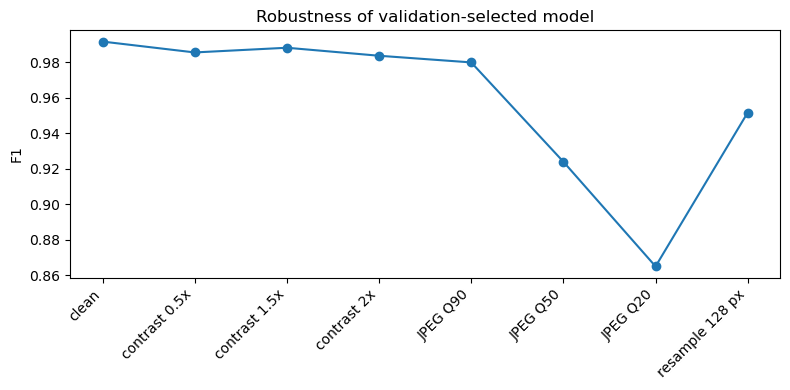

In [7]:
robustness_path = CONFIG.output_dir / f"tables/{best_name}_robustness.csv"
if robustness_path.exists():
    robustness = pd.read_csv(robustness_path)
else:
    robustness = evaluate_robustness(
        best_model, test_df, nn.BCEWithLogitsLoss(), device,
        CONFIG.image_size, CONFIG.batch_size, CONFIG.num_workers, CONFIG.threshold,
    )
    robustness.to_csv(robustness_path, index=False)
display(robustness)
labels = [
    (
        "clean"
        if condition == "clean"
        else f"contrast {value:g}x"
        if condition == "contrast"
        else f"JPEG Q{int(value)}"
        if condition == "jpeg"
        else f"resample {int(value)} px"
    )
    for condition, value in zip(robustness["condition"], robustness["value"], strict=True)
]
plt.figure(figsize=(8, 4))
plt.plot(labels, robustness.f1, marker="o")
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1")
plt.title("Robustness of validation-selected model")
plt.tight_layout()
plt.savefig(CONFIG.output_dir / f"figures/{best_name}_robustness_f1.png", dpi=200)
plt.show()

## 6. Grad-CAM

These maps show sensitivity, not causal reasoning. Compare correct real, correct fake, and error cases.

In [8]:
written_panels = save_gradcam_panels(
    best_model, best_row.model_name, best_predictions,
    CONFIG.output_dir / "figures", device,
    image_size=CONFIG.image_size, seed=CONFIG.seed,
)
written_panels

[PosixPath('/home/utente/giuseppe/intro_ml_2/outputs/figures/gradcam_correct_real.png'),
 PosixPath('/home/utente/giuseppe/intro_ml_2/outputs/figures/gradcam_correct_fake.png'),
 PosixPath('/home/utente/giuseppe/intro_ml_2/outputs/figures/gradcam_misclassified.png')]

## 7. Independent replication and overfitting audit

This post-training audit uses a second, disjoint 2,000-image official-test subset. All checkpoints are frozen. The clean training and replication evaluations use direct 224-by-224 resizing only; the 128-to-224 robustness resampling condition is not mixed into these results.

,exp_name,train_clean_f1,original_test_f1,replication_f1,replication_f1_ci_low,replication_f1_ci_high,train_replication_f1_gap,replication_original_f1_delta
0,E0_mobilenetv2_noaug_frozen,0.954160,0.941700,0.938856,0.929687,0.948415,0.015304,-0.002844
1,E1_mobilenetv2_aug_frozen,0.947073,0.940411,0.937718,0.927287,0.948212,0.009355,-0.002693
2,E2_convnext_tiny_aug_frozen,0.985308,0.977444,0.968547,0.961114,0.975488,0.016761,-0.008896
3,E3_convnext_tiny_aug_laststage,1.000000,0.991530,0.988529,0.984032,0.993021,0.011471,-0.003001
4,E4_convnext_tiny_se_aug_laststage,0.999687,0.989011,0.986974,0.981982,0.992000,0.012714,-0.002037


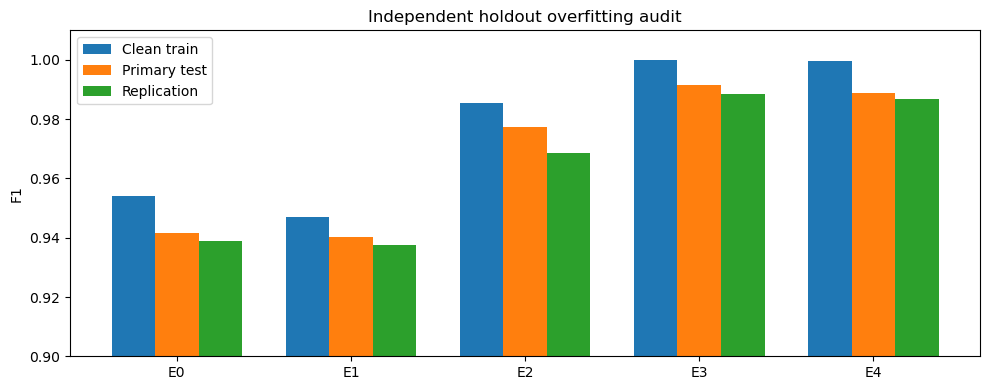

In [9]:
replication_root = CONFIG.output_dir / "replication"
replication_results_path = replication_root / "tables/replication_overfitting_results.csv"
if not replication_results_path.exists():
    raise FileNotFoundError(
        "Run `python scripts/evaluate_replication.py` before this section."
    )
replication_results = pd.read_csv(replication_results_path)
display(replication_results[[
    "exp_name", "train_clean_f1", "original_test_f1", "replication_f1",
    "replication_f1_ci_low", "replication_f1_ci_high",
    "train_replication_f1_gap", "replication_original_f1_delta",
]])

replication_figures = replication_root / "figures"
replication_figures.mkdir(parents=True, exist_ok=True)
plot_frame = replication_results.set_index("exp_name")
x = np.arange(len(plot_frame))
width = 0.25
figure, axis = plt.subplots(figsize=(10, 4))
axis.bar(x - width, plot_frame.train_clean_f1, width, label="Clean train")
axis.bar(x, plot_frame.original_test_f1, width, label="Primary test")
axis.bar(x + width, plot_frame.replication_f1, width, label="Replication")
axis.set_xticks(x, [name.split("_")[0] for name in plot_frame.index])
axis.set_ylim(0.9, 1.01)
axis.set_ylabel("F1")
axis.set_title("Independent holdout overfitting audit")
axis.legend()
figure.tight_layout()
figure.savefig(replication_figures / "replication_f1_comparison.png", dpi=200)
plt.show()

## 8. Report checklist

1. Report dataset counts and unknown-label audit.
2. Generate report fragments from `outputs/tables/experiment_results.csv`.
3. Compare augmentation (E0/E1), backbone (E1/E2), fine-tuning (E2/E3), and SE (E3/E4).
4. Include clean and perturbed metrics, subgroup tables, confusion matrix, ROC curve, and representative Grad-CAM panels.
5. Discuss born-digital versus scanned-image shortcuts, source artifacts, unseen generators, and subset limitations.
6. Never copy the paper's multiclass scores into this binary project's result table.
7. Run the disjoint replication audit without image resampling and report its confidence intervals.
8. Run `python scripts/make_latex_table.py`, then compile `report/report.tex`.